<a href="https://colab.research.google.com/github/hjfuentes/Laboratorio-Datos-Sociales/blob/main/Trading-Algoritmico/01-Fundamentos/Sesion_06_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Caso aplicado de series financieras
## De CAPM a ARIMAX con una empresa relacionada usando `yfinance`

En esta clase vamos a estudiar una pregunta muy concreta:

> **¿La información de Microsoft aporta valor adicional para explicar o anticipar los retornos de Apple, después de controlar por el comportamiento general del mercado?**

Trabajaremos con:

- **Apple (`AAPL`)** como activo objetivo.
- **Microsoft (`MSFT`)** como empresa relacionada.
- **S&P 500 (`^GSPC`)** como aproximación al mercado.
- **Treasury Bill a 13 semanas (`^IRX`)** como aproximación práctica a la tasa libre de riesgo.

La clase seguirá una secuencia progresiva:

$$
\boxed{
CAPM
\rightarrow
empresa\ relacionada
\rightarrow
estacionariedad
\rightarrow
ARIMA
\rightarrow
ARIMAX
\rightarrow
evaluación\ fuera\ de\ muestra
}
$$

La finalidad no es demostrar que una empresa "causa" los movimientos de otra. Nuestro objetivo será aprender a distinguir entre:

- asociación;
- explicación;
- información incremental;
- capacidad predictiva;
- utilidad económica.

## Objetivos de aprendizaje

Al finalizar esta clase deberías poder:

1. Descargar y organizar series financieras desde `yfinance`.
2. Diferenciar precio, retorno simple y retorno logarítmico.
3. Estimar e interpretar un modelo CAPM.
4. Analizar si el beta de mercado parece estable a través del tiempo.
5. Incorporar una empresa relacionada como factor adicional.
6. Evaluar estacionariedad mediante ADF y KPSS.
7. Construir un modelo ARIMA como referencia temporal.
8. Construir modelos ARIMAX utilizando `SARIMAX`.
9. Evitar fuga de información utilizando variables rezagadas.
10. Comparar modelos mediante AIC, BIC, MAE, RMSE y precisión direccional.
11. Realizar una evaluación *walk-forward* de un paso hacia adelante.
12. Analizar residuos y reconocer el puente hacia ARCH/GARCH.

# 1. Preparación del entorno

Si estás trabajando en Google Colab, ejecuta la siguiente celda una vez.

In [ ]:
!pip -q install yfinance statsmodels scikit-learn

## 1.1 Librerías

Utilizaremos `statsmodels` tanto para las regresiones financieras como para los modelos de series de tiempo.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

import statsmodels.api as sm

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.options.display.float_format = "{:,.6f}".format

# 2. Definición del caso

Dejaremos los tickers como parámetros.

Esto te permitirá repetir el análisis posteriormente con otros pares de empresas sin reescribir todo el notebook.

In [ ]:
TARGET = "AAPL"
PEER = "MSFT"
MARKET = "^GSPC"
RISK_FREE = "^IRX"

START = "2019-01-01"
END = None

TEST_SIZE = 0.20

MAX_P = 3
MAX_Q = 3

ROLLING_BETA_WINDOW = 126

### Otros pares que puedes probar después

- Coca-Cola (`KO`) vs Pepsi (`PEP`)
- JPMorgan (`JPM`) vs Bank of America (`BAC`)
- Exxon (`XOM`) vs Chevron (`CVX`)

La pregunta siempre será la misma:

> **¿La empresa relacionada contiene información que no estaba ya contenida en el mercado y en la historia del propio activo?**

# 3. Descarga de datos financieros

Utilizaremos precios ajustados mediante:

```python
auto_adjust=True
```

Esto permite trabajar con series que incorporan, cuando corresponde, ajustes por dividendos y *splits*.

In [ ]:
tickers = [TARGET, PEER, MARKET, RISK_FREE]

raw = yf.download(
    tickers,
    start=START,
    end=END,
    auto_adjust=True,
    progress=False
)

if raw.empty:
    raise ValueError("No se descargaron datos. Verifica la conexión a internet y los tickers.")

raw.head()

Price          Close                                      High            \
Ticker          AAPL      MSFT        ^GSPC     ^IRX      AAPL      MSFT   
Date                                                                       
2019-01-02 37.436916 94.016151 2,510.030029 2.365000 37.657386 94.601890   
2019-01-03 33.707909 90.557487 2,447.889893 2.355000 34.544739 93.151486   
2019-01-04 35.146889 94.769257 2,531.939941 2.358000 35.215639 95.308512   
2019-01-07 35.068649 94.890106 2,549.689941 2.353000 35.282008 96.015101   
2019-01-08 35.737175 95.578140 2,574.409912 2.400000 35.990834 96.665944   

Price                                  Low                                  \
Ticker            ^GSPC     ^IRX      AAPL      MSFT        ^GSPC     ^IRX   
Date                                                                         
2019-01-02 2,519.489990 2.400000 36.562155 91.989300 2,467.469971 2.360000   
2019-01-03 2,493.139893 2.368000 33.662866 90.371534 2,443.959961 2.355000   
2019-01-04 2,538.070068 2.373000 34.089592 91.980011 2,474.330078 2.358000   
2019-01-07 2,566.159912 2.370000 34.587413 93.885983 2,524.560059 2.353000   
2019-01-08 2,579.820068 2.403000 35.208527 94.564711 2,547.560059 2.388000   

Price           Open                                     Volume            \
Ticker          AAPL      MSFT        ^GSPC     ^IRX       AAPL      MSFT   
Date                                                                        
2019-01-02 36.718617 92.556447 2,476.959961 2.395000  148158800  35329300   
2019-01-03 34.132249 93.067805 2,491.919922 2.363000  365248800  42579100   
2019-01-04 34.262647 92.714513 2,474.330078 2.358000  234428400  44060600   
2019-01-07 35.251188 94.499614 2,535.610107 2.355000  219111200  35656100   
2019-01-08 35.455070 95.801278 2,568.110107 2.395000  164101200  31514400   

Price                        
Ticker           ^GSPC ^IRX  
Date                         
2019-01-02  3733160000    0  
2019-01-03  3858830000    0  
2019-01-04  4234140000    0  
2019-01-07  4133120000    0  
2019-01-08  4120060000    0

In [ ]:
raw = raw.resample('D').interpolate(method='akima').copy()

## 3.1 Extraer precios de cierre

Cuando descargamos varios activos, `yfinance` utiliza columnas jerárquicas. Nos quedaremos con el bloque `Close`.

In [ ]:
close = raw["Close"].copy()
close.columns = [str(col) for col in close.columns]

required = [TARGET, PEER, MARKET, RISK_FREE]
missing = [col for col in required if col not in close.columns]

if missing:
    raise ValueError(f"No se encontraron estos tickers en la descarga: {missing}")

close = close[required].sort_index()

close.tail()

,AAPL,MSFT,^GSPC,^IRX
Date,,,,
2026-09-11,332.269989,495.630005,"7,656.979980",3.913000
2026-09-12,334.338968,498.881345,"7,654.178144",3.927724
2026-09-13,334.614474,502.134008,"7,642.775919",3.926801
2026-09-14,333.079987,505.410004,"7,619.979980",3.935000
2026-09-15,NaN,NaN,"7,585.729980",3.960000


## 3.2 Verificación inicial

Antes de estimar cualquier modelo revisamos:

- rango temporal;
- número de observaciones;
- datos faltantes.

Un buen análisis financiero comienza por comprobar que las series estén correctamente alineadas.

In [ ]:
print("Primera fecha :", close.index.min())
print("Última fecha  :", close.index.max())
print("Observaciones :", len(close))

pd.DataFrame({
    "faltantes": close.isna().sum(),
    "porcentaje_%": close.isna().mean() * 100
})

Primera fecha : 2019-01-02 00:00:00
Última fecha  : 2026-09-15 00:00:00
Observaciones : 2814


,faltantes,porcentaje_%
AAPL,1,0.035537
MSFT,1,0.035537
^GSPC,0,0.000000
^IRX,0,0.000000


# 4. Construcción de variables financieras

Trabajaremos con dos definiciones de retorno.

### Retorno simple

$$
R_t=\frac{P_t}{P_{t-1}}-1
$$

### Retorno logarítmico

$$
r_t=\ln(P_t)-\ln(P_{t-1})
$$

El retorno simple será útil para presentar CAPM.

El retorno logarítmico será nuestra variable principal en el bloque de series de tiempo.

Creando data frame vacio

In [ ]:
data = pd.DataFrame(index=close.index)

In [ ]:
data

""
Date
2019-01-02
2019-01-03
2019-01-04
2019-01-05
2019-01-06
...
2026-09-11
2026-09-12
2026-09-13


data solo tiene indices de fechas

Aqui estamos transladando/pegando las columnas con los precios de la empresa objetivo, el activo paralelo y los datos del mercado.

In [ ]:
data["target_price"] = close[TARGET]
data["peer_price"] = close[PEER]
data["market_price"] = close[MARKET]

In [ ]:
data.head()

,target_price,peer_price,market_price
Date,,,
2019-01-02,37.436916,94.016151,"2,510.030029"
2019-01-03,33.707909,90.557487,"2,447.889893"
2019-01-04,35.146889,94.769257,"2,531.939941"
2019-01-05,35.049833,94.830111,"2,538.277064"
2019-01-06,34.837055,94.674405,"2,538.677930"


Ahora colocamos los retornos simples y llamamos a esas columnas retornos_simples_target,...

In [ ]:
data["target_ret_simple"] = close[TARGET].pct_change()
data["peer_ret_simple"] = close[PEER].pct_change()
data["market_ret_simple"] = close[MARKET].pct_change()

`.pct_change()` es para calcular variaciones porcentuales.

In [ ]:
data["target_ret"] = np.log(close[TARGET]).diff()
data["peer_ret"] = np.log(close[PEER]).diff()
data["market_ret"] = np.log(close[MARKET]).diff()

In [ ]:
data.head()

,target_price,peer_price,market_price,target_ret_simple,peer_ret_simple,market_ret_simple,target_ret,peer_ret,market_ret
Date,,,,,,,,,
2019-01-02,37.436916,94.016151,"2,510.030029",NaN,NaN,NaN,NaN,NaN,NaN
2019-01-03,33.707909,90.557487,"2,447.889893",-0.099608,-0.036788,-0.024757,-0.104925,-0.037482,-0.025068
2019-01-04,35.146889,94.769257,"2,531.939941",0.042690,0.046509,0.034336,0.041804,0.045460,0.033759
2019-01-05,35.049833,94.830111,"2,538.277064",-0.002761,0.000642,0.002503,-0.002765,0.000642,0.002500
2019-01-06,34.837055,94.674405,"2,538.677930",-0.006071,-0.001642,0.000158,-0.006089,-0.001643,0.000158


Aqui calculamos el retorno logaritmico

In [ ]:
close[RISK_FREE] / 100

,^IRX
Date,
2019-01-02,0.023650
2019-01-03,0.023550
2019-01-04,0.023580
2019-01-05,0.023572
2019-01-06,0.023538
...,...
2026-09-11,0.039130
2026-09-12,0.039277
2026-09-13,0.039268


In [ ]:
rf_annual = close[RISK_FREE].ffill() / 100

In [ ]:
rf_annual

,^IRX
Date,
2019-01-02,0.023650
2019-01-03,0.023550
2019-01-04,0.023580
2019-01-05,0.023572
2019-01-06,0.023538
...,...
2026-09-11,0.039130
2026-09-12,0.039277
2026-09-13,0.039268


In [ ]:
rf_annual = close[RISK_FREE].ffill() / 100
data["rf_daily"] = (1 + rf_annual) ** (1 / 252) - 1

data = data.dropna()

data.tail()

,target_price,peer_price,market_price,target_ret_simple,peer_ret_simple,market_ret_simple,target_ret,peer_ret,market_ret,rf_daily
Date,,,,,,,,,,
2026-09-10,326.570007,492.440002,"7,591.700195",0.035612,0.001607,-0.005848,0.034993,0.001606,-0.005865,0.000150
2026-09-11,332.269989,495.630005,"7,656.979980",0.017454,0.006478,0.008599,0.017304,0.006457,0.008562,0.000152
2026-09-12,334.338968,498.881345,"7,654.178144",0.006227,0.006560,-0.000366,0.006207,0.006539,-0.000366,0.000153
2026-09-13,334.614474,502.134008,"7,642.775919",0.000824,0.006520,-0.001490,0.000824,0.006499,-0.001491,0.000153
2026-09-14,333.079987,505.410004,"7,619.979980",-0.004586,0.006524,-0.002983,-0.004596,0.006503,-0.002987,0.000153


### Sobre la tasa libre de riesgo

`^IRX` será utilizada como una aproximación práctica a una tasa corta en dólares.

Para una aplicación profesional podríamos utilizar una fuente oficial y construir una tasa exactamente coherente con:

- moneda;
- horizonte;
- convención de días;
- periodicidad del modelo.

Aquí priorizamos una construcción reproducible usando datos accesibles desde Python.

# 5. Exploración visual

Primero observaremos los precios de las dos empresas.

No utilizaremos este gráfico para afirmar que una empresa sigue a la otra. Simplemente buscamos reconocer tendencias, periodos comunes y cambios de escala.

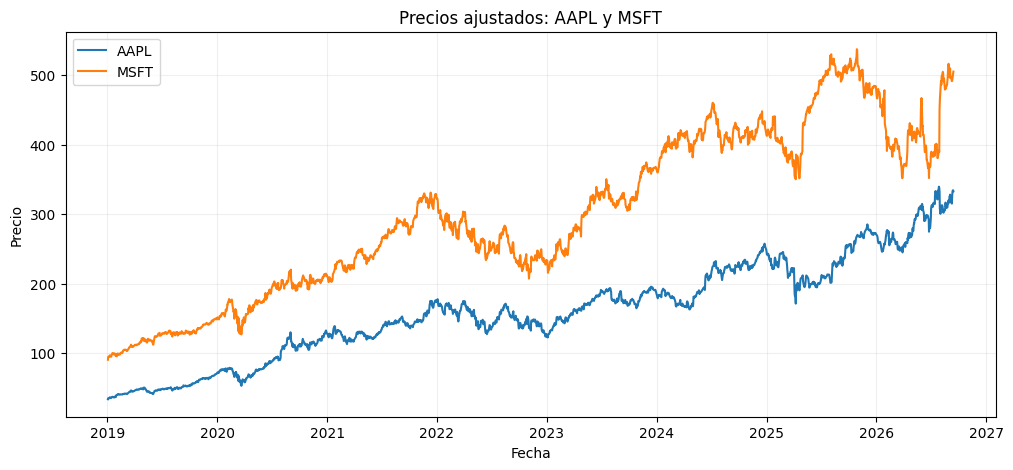

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(data.index, data["target_price"], label=TARGET)
plt.plot(data.index, data["peer_price"], label=PEER)
plt.title(f"Precios ajustados: {TARGET} y {PEER}")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 5.1 Retornos del activo objetivo

En series financieras suele ser más útil modelar retornos que precios directamente.

Observa especialmente los periodos donde la amplitud de los movimientos aumenta.

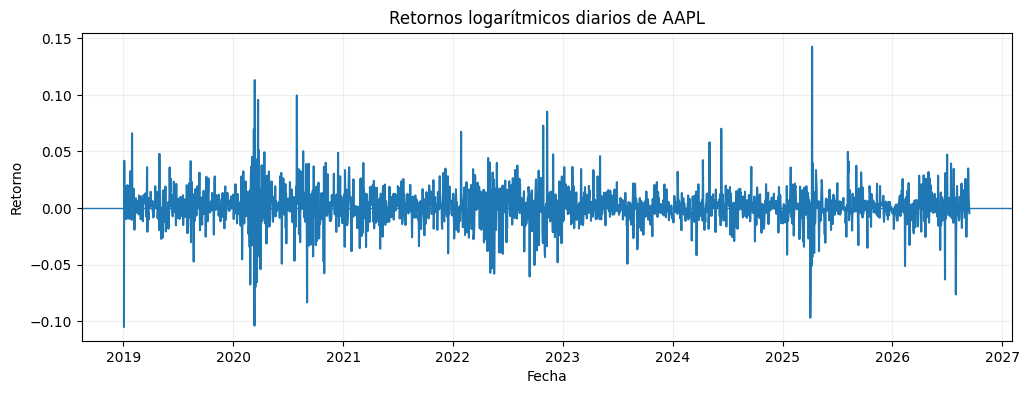

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(data.index, data["target_ret"])
plt.axhline(0, linewidth=1)
plt.title(f"Retornos logarítmicos diarios de {TARGET}")
plt.xlabel("Fecha")
plt.ylabel("Retorno")
plt.grid(alpha=0.2)
plt.show()

## 5.2 Estadísticos descriptivos

Los retornos financieros suelen presentar:

- media pequeña;
- volatilidad variable;
- asimetría;
- curtosis elevada;
- observaciones extremas.

Esto será relevante cuando más adelante estudiemos ARCH/GARCH.

In [ ]:
ret_cols = ["target_ret", "peer_ret", "market_ret"]

summary = data[ret_cols].describe().T
summary["skew"] = data[ret_cols].skew()
summary["kurtosis"] = data[ret_cols].kurtosis()

summary

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
target_ret,"2,812.000000",0.000777,0.014843,-0.104925,-0.005097,0.000714,0.006608,0.142617,0.114004,11.014586
peer_ret,"2,812.000000",0.000598,0.014294,-0.105284,-0.004868,0.000436,0.006231,0.144159,0.433819,12.736605
market_ret,"2,812.000000",0.000395,0.009468,-0.099945,-0.002715,0.000527,0.003930,0.090895,-0.095417,18.772818


# 6. CAPM: nuestra primera referencia financiera

Construiremos retornos en exceso:

$$
R^e_{i,t}=R_{i,t}-R_{f,t}
$$

y estimaremos:

$$
R^e_{AAPL,t}
=
\alpha+\beta_mR^e_{MKT,t}+\varepsilon_t
$$

### Interpretación

- $\alpha$: intercepto de la regresión.
- $\beta_m$: sensibilidad del activo al mercado.
- $R^2$: proporción de variabilidad explicada por el mercado.

Utilizaremos errores estándar robustos `HC1`.

In [ ]:
capm = pd.DataFrame(index=data.index)
capm.head()

""
Date
2019-01-03
2019-01-04
2019-01-05
2019-01-06
2019-01-07


In [ ]:
capm["target_excess"] = data["target_ret_simple"] - data["rf_daily"]
capm["market_excess"] = data["market_ret_simple"] - data["rf_daily"]

In [ ]:
X_capm = sm.add_constant(capm["market_excess"])
X_capm

,const,market_excess
Date,,
2019-01-03,1.000000,-0.024849
2019-01-04,1.000000,0.034243
2019-01-05,1.000000,0.002410
2019-01-06,1.000000,0.000066
2019-01-07,1.000000,0.004245
...,...,...
2026-09-10,1.000000,-0.005998
2026-09-11,1.000000,0.008447
2026-09-12,1.000000,-0.000519


In [ ]:
y_capm = capm["target_excess"]
y_capm

,target_excess
Date,
2019-01-03,-0.099700
2019-01-04,0.042597
2019-01-05,-0.002854
2019-01-06,-0.006163
2019-01-07,0.006556
...,...
2026-09-10,0.035463
2026-09-11,0.017302
2026-09-12,0.006074


In [ ]:
capm_model = sm.OLS(
    y_capm,
    X_capm
).fit(cov_type="HC1")

print(capm_model.summary())

                            OLS Regression Results                            
Dep. Variable:          target_excess   R-squared:                       0.560
Model:                            OLS   Adj. R-squared:                  0.560
Method:                 Least Squares   F-statistic:                     1312.
Date:                Wed, 16 Sep 2026   Prob (F-statistic):          3.95e-236
Time:                        02:09:28   Log-Likelihood:                 8996.2
No. Observations:                2812   AIC:                        -1.799e+04
Df Residuals:                    2810   BIC:                        -1.798e+04
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0004      0.000      2.092

In [ ]:
alpha_capm = capm_model.params["const"]
beta_capm = capm_model.params["market_excess"]

capm_metrics = pd.Series({
    "alpha_diario": alpha_capm,
    "beta_mercado": beta_capm,
    "R2": capm_model.rsquared,
    "R2_ajustado": capm_model.rsquared_adj,
    "p_value_alpha": capm_model.pvalues["const"],
    "p_value_beta": capm_model.pvalues["market_excess"]
})

capm_metrics

,0
alpha_diario,0.000389
beta_mercado,1.175597
R2,0.559906
R2_ajustado,0.559750
p_value_alpha,0.036435
p_value_beta,0.000000


### Cómo leer el beta

De manera orientativa:

- $\beta>1$: el activo ha mostrado mayor sensibilidad que el mercado.
- $0<\beta<1$: sensibilidad menor que la del mercado.
- $\beta<0$: relación inversa histórica, algo menos frecuente en acciones tradicionales.

No conviertas esta lectura en una regla de inversión. El beta es una estimación histórica y puede cambiar.

# 7. ¿El beta permanece constante?

CAPM nos entrega un único beta para toda la muestra.

Ahora calcularemos un beta móvil:

$$
\beta_t=
\frac{Cov(R_i,R_m)}{Var(R_m)}
$$

Usaremos una ventana de 126 ruedas bursátiles, aproximadamente medio año.

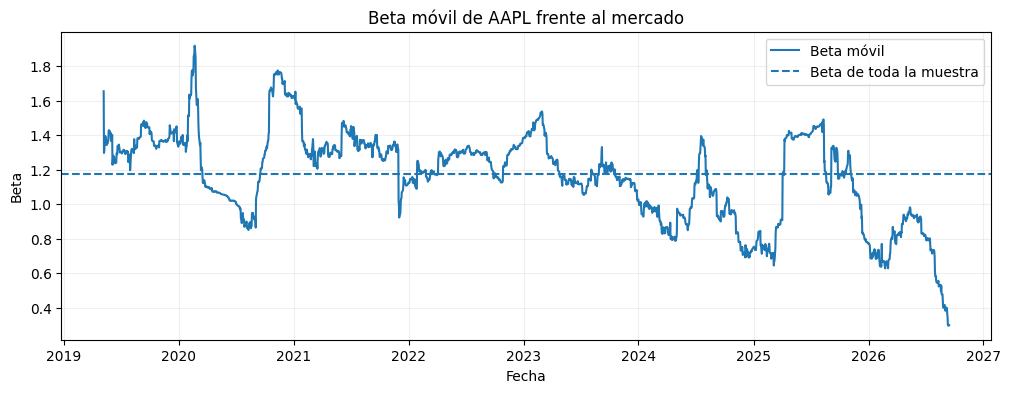

In [ ]:
rolling_cov = capm["target_excess"].rolling(
    ROLLING_BETA_WINDOW
).cov(capm["market_excess"])

rolling_var = capm["market_excess"].rolling(
    ROLLING_BETA_WINDOW
).var()

rolling_beta = rolling_cov / rolling_var

plt.figure(figsize=(12, 4))
plt.plot(rolling_beta.index, rolling_beta, label="Beta móvil")
plt.axhline(
    beta_capm,
    linestyle="--",
    label="Beta de toda la muestra"
)
plt.title(f"Beta móvil de {TARGET} frente al mercado")
plt.xlabel("Fecha")
plt.ylabel("Beta")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

### Pregunta para reflexionar

Si observas cambios importantes en el beta móvil:

> **¿Qué limitación tendría utilizar un único beta histórico para describir todos los periodos de la empresa?**

Esta pregunta nos prepara para pensar en relaciones financieras que pueden evolucionar con el tiempo.

# 8. Incorporamos una empresa relacionada

Ampliaremos el modelo:

$$
R^e_{AAPL,t}
=
\alpha
+
\beta_mR^e_{MKT,t}
+
\beta_pR^e_{MSFT,t}
+
\varepsilon_t
$$

La nueva pregunta será:

> **Después de controlar por el mercado, Microsoft aporta información adicional para explicar los movimientos diarios de Apple?**

Esta regresión es contemporánea. Nos ayuda a estudiar asociación y explicación, pero todavía no constituye un ejercicio predictivo.

In [ ]:
peer_reg = pd.DataFrame(index=data.index)

peer_reg["target_excess"] = data["target_ret_simple"] - data["rf_daily"]
peer_reg["market_excess"] = data["market_ret_simple"] - data["rf_daily"]
peer_reg["peer_excess"] = data["peer_ret_simple"] - data["rf_daily"]
peer_reg.head()

,target_excess,market_excess,peer_excess
Date,,,
2019-01-03,-0.099700,-0.024849,-0.036880
2019-01-04,0.042597,0.034243,0.046417
2019-01-05,-0.002854,0.002410,0.000550
2019-01-06,-0.006163,0.000066,-0.001734
2019-01-07,0.006556,0.004245,0.002186


In [ ]:
X_peer = sm.add_constant(
    peer_reg[["market_excess", "peer_excess"]]
)

X_peer.head()

,const,market_excess,peer_excess
Date,,,
2019-01-03,1.000000,-0.024849,-0.036880
2019-01-04,1.000000,0.034243,0.046417
2019-01-05,1.000000,0.002410,0.000550
2019-01-06,1.000000,0.000066,-0.001734
2019-01-07,1.000000,0.004245,0.002186


In [ ]:
#X_peer['const'] = X_peer['market_excess']

In [ ]:
y_peer = peer_reg["target_excess"]

peer_model = sm.OLS(
    y_peer,
    X_peer
).fit(cov_type="HC1")

print(peer_model.summary())

                            OLS Regression Results                            
Dep. Variable:          target_excess   R-squared:                       0.570
Model:                            OLS   Adj. R-squared:                  0.570
Method:                 Least Squares   F-statistic:                     680.9
Date:                Wed, 16 Sep 2026   Prob (F-statistic):          7.58e-242
Time:                        02:50:08   Log-Likelihood:                 9030.2
No. Observations:                2812   AIC:                        -1.805e+04
Df Residuals:                    2809   BIC:                        -1.804e+04
Df Model:                           2                                         
Covariance Type:                  HC1                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0004      0.000      1.937

## 8.1 CAPM vs mercado + empresa relacionada

El $R^2$ nos indica capacidad explicativa dentro de muestra.

AIC y BIC agregan una penalización por complejidad.

In [ ]:
regression_comparison = pd.DataFrame({
    "Modelo": [
        "CAPM",
        "Mercado + empresa relacionada"
    ],
    "R2": [
        capm_model.rsquared,
        peer_model.rsquared
    ],
    "R2_ajustado": [
        capm_model.rsquared_adj,
        peer_model.rsquared_adj
    ],
    "AIC": [
        capm_model.aic,
        peer_model.aic
    ],
    "BIC": [
        capm_model.bic,
        peer_model.bic
    ]
})

regression_comparison

,Modelo,R2,R2_ajustado,AIC,BIC
0,CAPM,0.559906,0.559750,"-17,988.476642","-17,976.593340"
1,Mercado + empresa relacionada,0.570407,0.570101,"-18,054.385761","-18,036.560807"


# 9. ¿El peer aporta información diferente o simplemente repite al mercado?

Una empresa grande como Microsoft forma parte del propio entorno de mercado.

Por eso debemos revisar si nuestras variables explicativas están fuertemente relacionadas.

Primero observaremos correlaciones.

In [ ]:
corr_table = peer_reg[
    ["target_excess", "market_excess", "peer_excess"]
].corr()

corr_table

,target_excess,market_excess,peer_excess
target_excess,1.000000,0.748269,0.629272
market_excess,0.748269,1.000000,0.750459
peer_excess,0.629272,0.750459,1.000000


## 9.1 VIF como apoyo para estudiar multicolinealidad

El **Variance Inflation Factor (VIF)** ayuda a detectar si una X puede explicarse en gran medida por las otras X.

No existe un único umbral universal, pero valores elevados deben hacernos revisar la especificación.

In [ ]:
vif_X = peer_reg[
    ["market_excess", "peer_excess"]
].copy()

vif_X = sm.add_constant(vif_X)

vif_table = pd.DataFrame({
    "Variable": vif_X.columns,
    "VIF": [
        variance_inflation_factor(vif_X.values, i)
        for i in range(vif_X.shape[1])
    ]
})

vif_table

,Variable,VIF
0,const,1.000000
1,market_excess,2.289318
2,peer_excess,2.289318


### Lectura docente

Si `peer_excess` está muy correlacionado con `market_excess`, puede mejorar el ajuste y, al mismo tiempo, dificultar la interpretación individual de los coeficientes.

Por eso debemos separar:

- **capacidad explicativa conjunta**;
- **interpretación individual de cada beta**.

# 10. Estacionariedad

Entramos ahora al bloque de series de tiempo.

Antes de construir ARIMA debemos estudiar si la variable objetivo es estacionaria.

### ADF

$$
H_0:\text{existe raíz unitaria}
$$

Un p-value pequeño favorece rechazar la hipótesis de no estacionariedad.

### KPSS

$$
H_0:\text{la serie es estacionaria}
$$

Un p-value pequeño constituye evidencia contra la estacionariedad.

Utilizaremos ambas pruebas junto con la inspección visual.

In [ ]:
def stationarity_report(series, name="Serie"):
    s = pd.Series(series).dropna().astype(float)

    adf_result = adfuller(s, autolag="AIC")
    kpss_result = kpss(
        s,
        regression="c",
        nlags="auto"
    )

    result = pd.DataFrame({
        "Prueba": ["ADF", "KPSS"],
        "Estadístico": [
            adf_result[0],
            kpss_result[0]
        ],
        "p_value": [
            adf_result[1],
            kpss_result[1]
        ],
        "Hipótesis_nula": [
            "Raíz unitaria / no estacionaria",
            "Serie estacionaria"
        ]
    })

    print(f"Pruebas de estacionariedad: {name}")
    return result

In [ ]:
stationarity_report(
    np.log(data["target_price"]),
    f"Log-precio de {TARGET}"
)

Pruebas de estacionariedad: Log-precio de AAPL


/tmp/ipykernel_980/305312878.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_result = kpss(


,Prueba,Estadístico,p_value,Hipótesis_nula
0,ADF,-2.169614,0.217458,Raíz unitaria / no estacionaria
1,KPSS,7.594435,0.010000,Serie estacionaria


In [ ]:
stationarity_report(
    data["target_ret"],
    f"Retorno logarítmico de {TARGET}"
)

Pruebas de estacionariedad: Retorno logarítmico de AAPL


/tmp/ipykernel_980/305312878.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_result = kpss(


,Prueba,Estadístico,p_value,Hipótesis_nula
0,ADF,-11.699407,0.000000,Raíz unitaria / no estacionaria
1,KPSS,0.187335,0.100000,Serie estacionaria


### ¿Por qué modelaremos retornos con $d=0$?

El retorno logarítmico ya representa una diferencia:

$$
r_t=\ln(P_t)-\ln(P_{t-1})
$$

Si la serie de retornos es razonablemente estacionaria, nuestra especificación será:

$$
ARIMA(p,0,q)
$$

Esto equivale a modelar directamente la dinámica ARMA de los retornos.

# 11. ACF y PACF

Estas herramientas permiten explorar dependencia temporal.

- **ACF:** correlación con rezagos de la propia serie.
- **PACF:** correlación parcial descontando rezagos intermedios.

No utilizaremos ACF/PACF como una receta automática. Serán una guía inicial que luego complementaremos con AIC, BIC y evaluación fuera de muestra.

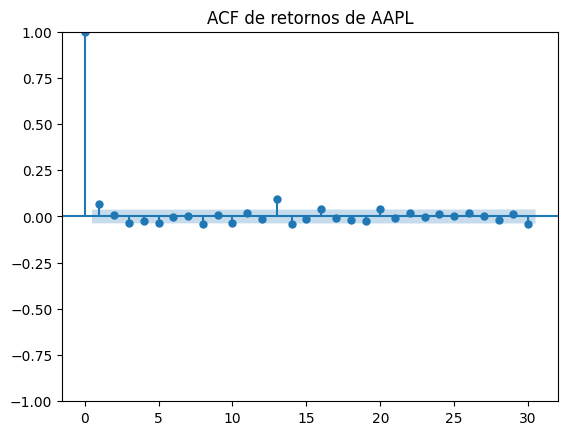

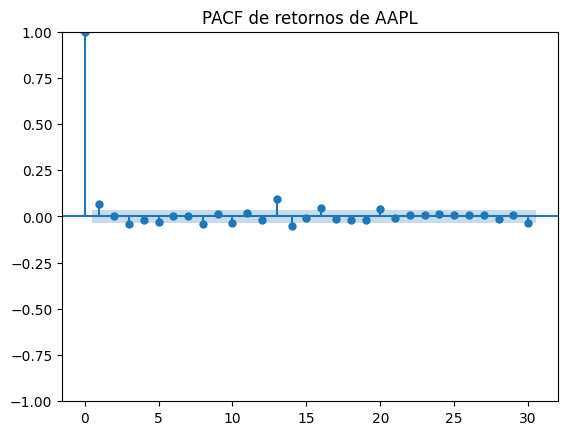

In [ ]:
fig = plot_acf(
    data["target_ret"],
    lags=30
)
plt.title(f"ACF de retornos de {TARGET}")
plt.show()

fig = plot_pacf(
    data["target_ret"],
    lags=30,
    method="ywm"
)
plt.title(f"PACF de retornos de {TARGET}")
plt.show()

# 12. De explicación a predicción

Hasta ahora utilizamos variables contemporáneas.

Para pronosticar debemos preguntarnos:

> **¿Qué información estaría realmente disponible en el momento de emitir el pronóstico?**

Si deseamos anticipar el retorno de Apple en $t$, no deberíamos utilizar el retorno final de Microsoft del mismo periodo $t$.

Por ello construiremos:

$$
X_{t-1}
\rightarrow
Y_t
$$

Es decir:

$$
r^{AAPL}_t
=
f(
r^{MKT}_{t-1},
r^{MSFT}_{t-1},
\text{historia de }r^{AAPL}
)
$$

Esta será nuestra estructura predictiva principal.

In [ ]:
predictive = pd.DataFrame(index=data.index)

predictive["date"] = data.index
predictive["y"] = data["target_ret"]

predictive["market_lag1"] = data["market_ret"].shift(1)
predictive["peer_lag1"] = data["peer_ret"].shift(1)

predictive = predictive.dropna().reset_index(drop=True)

predictive.head()

,date,y,market_lag1,peer_lag1
0,2019-01-04,0.041804,-0.025068,-0.037482
1,2019-01-05,-0.002765,0.033759,0.045460
2,2019-01-06,-0.006089,0.002500,0.000642
3,2019-01-07,0.006626,0.000158,-0.001643
4,2019-01-08,0.018884,0.004328,0.002276


### Una decisión técnica importante

Para estimar ARIMA/ARIMAX trabajaremos internamente con observaciones consecutivas:

$$
t=0,1,2,\ldots,T
$$

Cada observación representa una rueda bursátil consecutiva.

Las fechas reales se conservarán en la columna `date` para:

- gráficos;
- interpretación;
- presentación de resultados.

# 13. Separación temporal

Reservaremos el último 20 % de la muestra para evaluación.

No mezclaremos aleatoriamente los registros porque en una serie de tiempo el orden contiene información.

In [ ]:
split = int(len(predictive) * (1 - TEST_SIZE))

train = predictive.iloc[:split].copy()
test = predictive.iloc[split:].copy()

In [ ]:
train_dates = pd.DatetimeIndex(train["date"])
test_dates = pd.DatetimeIndex(test["date"])

print("TRAIN")
print(train_dates.min(), "→", train_dates.max())
print("Observaciones:", len(train))

print("\nTEST")
print(test_dates.min(), "→", test_dates.max())
print("Observaciones:", len(test))

TRAIN
2019-01-04 00:00:00 → 2025-02-28 00:00:00
Observaciones: 2248

TEST
2025-03-01 00:00:00 → 2026-09-14 00:00:00
Observaciones: 563


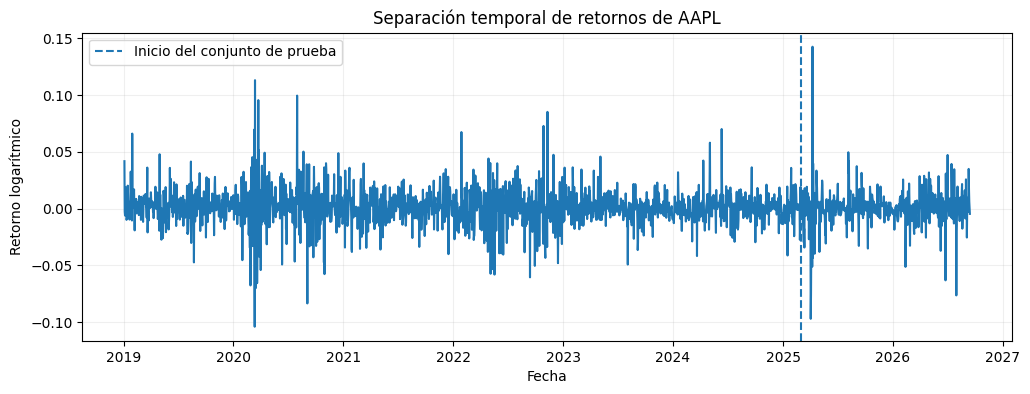

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(
    predictive["date"],
    predictive["y"]
)
plt.axvline(
    test_dates[0],
    linestyle="--",
    label="Inicio del conjunto de prueba"
)
plt.title(f"Separación temporal de retornos de {TARGET}")
plt.xlabel("Fecha")
plt.ylabel("Retorno logarítmico")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# 14. Series para modelamiento

Construiremos un índice secuencial interno.

Así el modelo interpreta cada fila como una observación bursátil consecutiva, mientras nosotros mantenemos las fechas reales por separado.

In [ ]:
n_train = len(train)
n_test = len(test)

train_index = pd.RangeIndex(
    start=0,
    stop=n_train,
    step=1
)

test_index = pd.RangeIndex(
    start=n_train,
    stop=n_train + n_test,
    step=1
)

y_train = pd.Series(
    train["y"].to_numpy(),
    index=train_index,
    name="y"
)

y_test_model = pd.Series(
    test["y"].to_numpy(),
    index=test_index,
    name="y"
)

y_test = pd.Series(
    test["y"].to_numpy(),
    index=test_dates,
    name="y"
)

print(y_train.head())
print()
print(y_test_model.head())

0    0.041804
1   -0.002765
2   -0.006089
3    0.006626
4    0.018884
Name: y, dtype: float64

2248   -0.003633
2249   -0.005236
2250   -0.007011
2251   -0.008862
2252   -0.000806
Name: y, dtype: float64


# 15. Benchmark sencillo

Antes de construir un modelo sofisticado debemos tener una referencia simple.

Para retornos diarios utilizaremos:

$$
\hat r_t=0
$$

Este benchmark responde a una idea sencilla:

> Si nuestro modelo complejo no supera consistentemente una predicción trivial, debemos ser prudentes al hablar de capacidad predictiva.

In [ ]:
pred_zero = pd.Series(
    0.0,
    index=test_dates,
    name="Naive"
)


def regression_metrics(y_true, y_pred):
    true = np.asarray(y_true, dtype=float)
    pred = np.asarray(y_pred, dtype=float)

    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))

    non_zero = pred != 0

    if non_zero.any():
        directional_accuracy = (
            np.sign(true[non_zero]) == np.sign(pred[non_zero])
        ).mean()
    else:
        directional_accuracy = np.nan

    return {
        "MAE": mae,
        "RMSE": rmse,
        "Directional_Accuracy": directional_accuracy
    }


baseline_metrics = regression_metrics(
    y_test,
    pred_zero
)

baseline_metrics

{'MAE': 0.00887777022824634,
 'RMSE': np.float64(0.014995791555523387),
 'Directional_Accuracy': nan}

# 16. Selección de un ARIMA base

Primero preguntaremos:

> **¿Cuánto podemos aprender utilizando solamente la historia del retorno de Apple?**

Buscaremos combinaciones de:

$$
p=0,\ldots,3
$$

$$
q=0,\ldots,3
$$

con:

$$
d=0
$$

La selección se realizará **exclusivamente con el conjunto de entrenamiento**.

In [ ]:
grid = []

for p in range(MAX_P + 1):
    for q in range(MAX_Q + 1):
        try:
            fitted = ARIMA(
                y_train,
                order=(p, 0, q),
                trend="c"
            ).fit()

            grid.append({
                "p": p,
                "d": 0,
                "q": q,
                "AIC": fitted.aic,
                "BIC": fitted.bic
            })

        except Exception:
            pass

grid_results = (
    pd.DataFrame(grid)
    .sort_values(["AIC", "BIC"])
    .reset_index(drop=True)
)

grid_results.head(10)

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


,p,d,q,AIC,BIC
0,3,0,0,"-12,619.298516","-12,590.709535"
1,2,0,3,"-12,618.893654","-12,578.869080"
2,0,0,3,"-12,618.768073","-12,590.179092"
3,2,0,2,"-12,618.324515","-12,584.017737"
4,0,0,1,"-12,617.906864","-12,600.753475"
5,1,0,3,"-12,617.606637","-12,583.299860"
6,1,0,0,"-12,617.388713","-12,600.235324"
7,3,0,1,"-12,617.166534","-12,582.859757"
8,2,0,0,"-12,617.144064","-12,594.272879"
9,1,0,2,"-12,616.863142","-12,588.274161"


In [ ]:
BEST_P = int(grid_results.loc[0, "p"])
BEST_Q = int(grid_results.loc[0, "q"])

print(
    f"Especificación temporal seleccionada: "
    f"ARIMA({BEST_P}, 0, {BEST_Q})"
)

Especificación temporal seleccionada: ARIMA(3, 0, 0)


### ¿Por qué mantendremos el mismo $p,q$?

Nuestro objetivo es estudiar el aporte incremental de las variables X.

Por ello:

1. seleccionamos una dinámica temporal base;
2. mantenemos esa dinámica;
3. agregamos mercado;
4. agregamos empresa relacionada.

Así la comparación se vuelve más clara para el alumno.

# 17. Preparación de variables exógenas

Compararemos tres especificaciones:

### Modelo A — ARIMA

$$
r_{AAPL,t}
=
ARMA(p,q)+\varepsilon_t
$$

### Modelo B — ARIMAX con mercado

$$
r_{AAPL,t}
=
\beta_m r_{MKT,t-1}
+
ARMA(p,q)
+
\varepsilon_t
$$

### Modelo C — ARIMAX con mercado + Microsoft

$$
r_{AAPL,t}
=
\beta_m r_{MKT,t-1}
+
\beta_p r_{MSFT,t-1}
+
ARMA(p,q)
+
\varepsilon_t
$$

In [ ]:
X_market_train_raw = train[
    ["market_lag1"]
].copy()

X_market_test_raw = test[
    ["market_lag1"]
].copy()

X_full_train_raw = train[
    ["market_lag1", "peer_lag1"]
].copy()

X_full_test_raw = test[
    ["market_lag1", "peer_lag1"]
].copy()


def standardize_train_test(X_train, X_test):
    mu = X_train.mean()
    sigma = X_train.std().replace(0, 1)

    X_train_std = (X_train - mu) / sigma
    X_test_std = (X_test - mu) / sigma

    return X_train_std, X_test_std, mu, sigma


(
    X_market_train_std,
    X_market_test_std,
    mu_market,
    sd_market
) = standardize_train_test(
    X_market_train_raw,
    X_market_test_raw
)

(
    X_full_train_std,
    X_full_test_std,
    mu_full,
    sd_full
) = standardize_train_test(
    X_full_train_raw,
    X_full_test_raw
)

## 17.1 Índice interno de las X

Las variables exógenas deben seguir exactamente el mismo orden temporal que la variable objetivo.

In [ ]:
X_market_train = pd.DataFrame(
    X_market_train_std.to_numpy(),
    index=train_index,
    columns=["market_lag1"]
)

X_market_test = pd.DataFrame(
    X_market_test_std.to_numpy(),
    index=test_index,
    columns=["market_lag1"]
)

X_full_train = pd.DataFrame(
    X_full_train_std.to_numpy(),
    index=train_index,
    columns=["market_lag1", "peer_lag1"]
)

X_full_test = pd.DataFrame(
    X_full_test_std.to_numpy(),
    index=test_index,
    columns=["market_lag1", "peer_lag1"]
)

X_full_train.head()

,market_lag1,peer_lag1
0,-2.620509,-2.708570
1,3.437849,3.185961
2,0.218582,0.000808
3,-0.022591,-0.161598
4,0.406896,0.116922


# 18. Estimación de ARIMA y ARIMAX

Utilizaremos la clase `SARIMAX` de `statsmodels`.

En esta clase no incorporaremos estacionalidad:

```python
seasonal_order=(0, 0, 0, 0)
```

Por tanto, la estructura económica que estamos estudiando es ARIMAX.

In [ ]:
model_arima = SARIMAX(
    y_train,
    order=(BEST_P, 0, BEST_Q),
    seasonal_order=(0, 0, 0, 0),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)


model_market = SARIMAX(
    y_train,
    exog=X_market_train,
    order=(BEST_P, 0, BEST_Q),
    seasonal_order=(0, 0, 0, 0),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)


model_full = SARIMAX(
    y_train,
    exog=X_full_train,
    order=(BEST_P, 0, BEST_Q),
    seasonal_order=(0, 0, 0, 0),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print("Modelos estimados.")

Modelos estimados.


# 19. Comparación dentro de muestra

AIC y BIC nos permiten comparar ajuste y complejidad.

Recuerda:

> Un menor AIC o BIC puede indicar una especificación más conveniente dentro de muestra, pero no garantiza mejor desempeño predictivo.

In [ ]:
information_criteria = pd.DataFrame({
    "Modelo": [
        "ARIMA",
        "ARIMAX: mercado",
        "ARIMAX: mercado + peer"
    ],
    "AIC": [
        model_arima.aic,
        model_market.aic,
        model_full.aic
    ],
    "BIC": [
        model_arima.bic,
        model_market.bic,
        model_full.bic
    ]
}).sort_values("AIC")

information_criteria

,Modelo,AIC,BIC
1,ARIMAX: mercado,"-12,618.617735","-12,584.318970"
2,ARIMAX: mercado + peer,"-12,616.617224","-12,576.601998"
0,ARIMA,"-12,607.629752","-12,579.047448"


# 20. Coeficientes del ARIMAX completo

Como estandarizamos las X, los coeficientes de `market_lag1` y `peer_lag1` se interpretan respecto a movimientos de una desviación estándar de cada factor.

Nos interesa estudiar:

- signo;
- magnitud;
- error estándar;
- p-value.

No confundas significancia estadística con causalidad.

In [ ]:
coef_table = pd.DataFrame({
    "coeficiente": model_full.params,
    "error_estandar": model_full.bse,
    "p_value": model_full.pvalues
})

coef_table

,coeficiente,error_estandar,p_value
intercept,0.000783,0.000316,0.013135
market_lag1,-0.001811,0.000369,0.000001
peer_lag1,-0.000009,0.000407,0.981747
ar.L1,0.171228,0.025559,0.000000
ar.L2,-0.044507,0.015507,0.004103
ar.L3,-0.039725,0.014399,0.005800
sigma2,0.000211,0.000003,0.000000


# 21. Evaluación condicional del bloque de prueba

Primero realizaremos una evaluación del bloque completo.

Las variables X del conjunto de prueba ya están construidas con un rezago de una rueda bursátil.

Esta evaluación nos permite comparar los tres modelos bajo una misma trayectoria observada de factores.

In [ ]:
forecast_arima = model_arima.get_forecast(
    steps=n_test
)

forecast_market = model_market.get_forecast(
    steps=n_test,
    exog=X_market_test
)

forecast_full = model_full.get_forecast(
    steps=n_test,
    exog=X_full_test
)


pred_arima_static = pd.Series(
    np.asarray(forecast_arima.predicted_mean),
    index=test_dates,
    name="ARIMA"
)

pred_market_static = pd.Series(
    np.asarray(forecast_market.predicted_mean),
    index=test_dates,
    name="ARIMAX_market"
)

pred_full_static = pd.Series(
    np.asarray(forecast_full.predicted_mean),
    index=test_dates,
    name="ARIMAX_market_peer"
)

print("Pronósticos generados.")

Pronósticos generados.


In [ ]:
static_results = pd.DataFrame([
    {
        "Modelo": "Naive = 0",
        **regression_metrics(
            y_test,
            pred_zero
        )
    },
    {
        "Modelo": "ARIMA",
        **regression_metrics(
            y_test,
            pred_arima_static
        )
    },
    {
        "Modelo": "ARIMAX: mercado",
        **regression_metrics(
            y_test,
            pred_market_static
        )
    },
    {
        "Modelo": "ARIMAX: mercado + peer",
        **regression_metrics(
            y_test,
            pred_full_static
        )
    }
])

static_results.sort_values("RMSE")

,Modelo,MAE,RMSE,Directional_Accuracy
1,ARIMA,0.008867,0.014989,0.523979
0,Naive = 0,0.008878,0.014996,NaN
3,ARIMAX: mercado + peer,0.009092,0.015077,0.476021
2,ARIMAX: mercado,0.009093,0.015078,0.476021


# 22. Pronóstico e incertidumbre

Un pronóstico puntual no cuenta toda la historia.

También debemos observar la incertidumbre asociada al pronóstico.

A continuación mostraremos intervalos de confianza del ARIMAX completo.

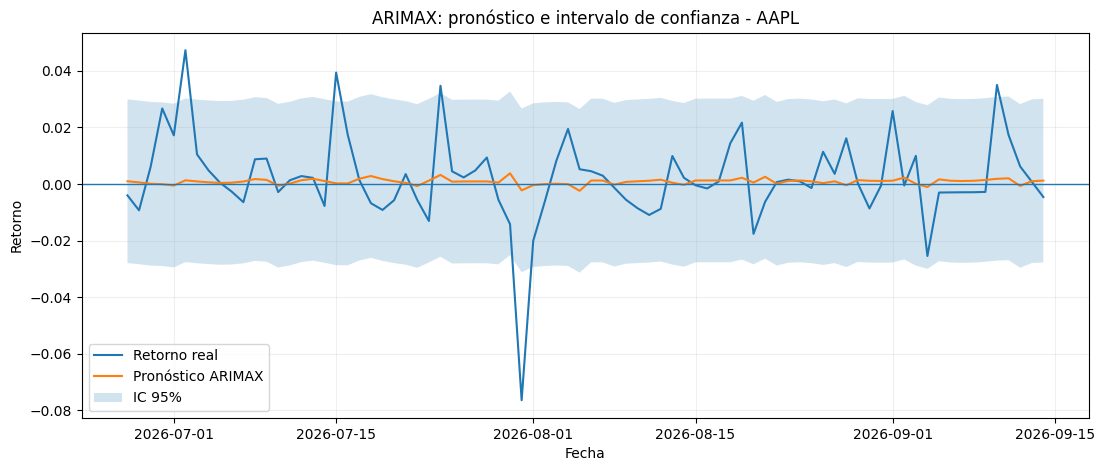

In [ ]:
ci_full = forecast_full.conf_int(alpha=0.05)

ci_lower = pd.Series(
    ci_full.iloc[:, 0].to_numpy(),
    index=test_dates
)

ci_upper = pd.Series(
    ci_full.iloc[:, 1].to_numpy(),
    index=test_dates
)

plot_n = min(80, len(y_test))

plt.figure(figsize=(13, 5))

plt.plot(
    y_test.index[-plot_n:],
    y_test.iloc[-plot_n:],
    label="Retorno real"
)

plt.plot(
    pred_full_static.index[-plot_n:],
    pred_full_static.iloc[-plot_n:],
    label="Pronóstico ARIMAX"
)

plt.fill_between(
    test_dates[-plot_n:],
    ci_lower.iloc[-plot_n:],
    ci_upper.iloc[-plot_n:],
    alpha=0.2,
    label="IC 95%"
)

plt.axhline(0, linewidth=1)
plt.title(
    f"ARIMAX: pronóstico e intervalo de confianza - {TARGET}"
)
plt.xlabel("Fecha")
plt.ylabel("Retorno")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

### Lectura importante

En retornos diarios, los intervalos pueden ser amplios respecto al pronóstico medio.

Esto nos recuerda que:

> **Predecir el retorno esperado y cuantificar su incertidumbre son problemas distintos.**

Una señal media pequeña puede coexistir con una incertidumbre considerable.

# 23. Comparación visual

Observaremos las últimas observaciones del periodo de prueba.

No esperes que el pronóstico siga perfectamente cada salto de la serie real. Los retornos diarios tienen una gran componente impredecible.

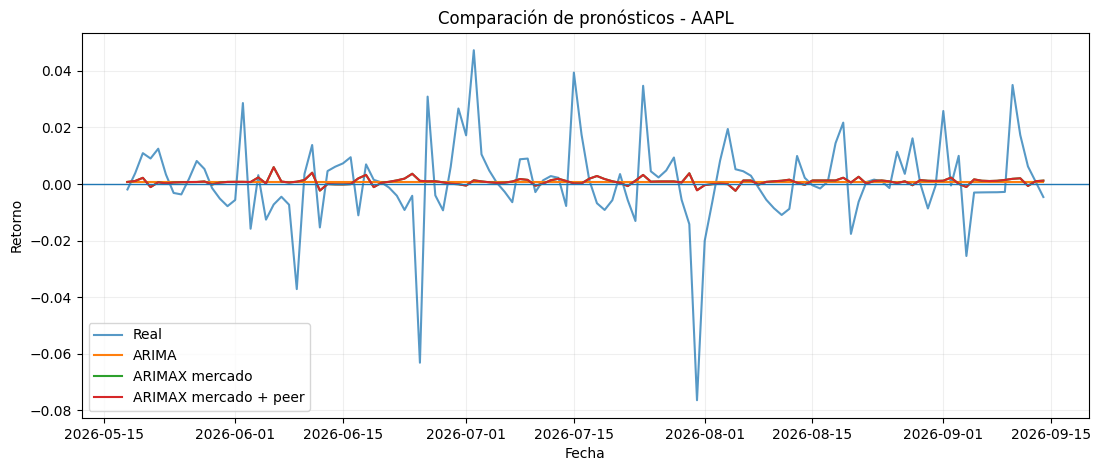

In [ ]:
plot_n = min(120, len(y_test))

plt.figure(figsize=(13, 5))

plt.plot(
    y_test.index[-plot_n:],
    y_test.iloc[-plot_n:],
    label="Real",
    alpha=0.75
)

plt.plot(
    pred_arima_static.index[-plot_n:],
    pred_arima_static.iloc[-plot_n:],
    label="ARIMA"
)

plt.plot(
    pred_market_static.index[-plot_n:],
    pred_market_static.iloc[-plot_n:],
    label="ARIMAX mercado"
)

plt.plot(
    pred_full_static.index[-plot_n:],
    pred_full_static.iloc[-plot_n:],
    label="ARIMAX mercado + peer"
)

plt.axhline(0, linewidth=1)
plt.title(f"Comparación de pronósticos - {TARGET}")
plt.xlabel("Fecha")
plt.ylabel("Retorno")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# 24. Evaluación principal: *walk-forward* de un paso hacia adelante

Ahora simularemos una dinámica más cercana al uso cotidiano del modelo.

Para cada rueda bursátil:

1. utilizamos la información disponible;
2. pronosticamos el siguiente retorno;
3. observamos el valor real;
4. incorporamos esa observación al estado del modelo;
5. avanzamos una rueda.

Esta evaluación es especialmente importante cuando hablamos de pronóstico financiero.

In [ ]:
def walk_forward_sarimax(
    fitted_model,
    y_test_seq,
    test_dates,
    X_test_seq=None
):
    # Pronóstico de un paso hacia adelante.
    # Los parámetros estimados se mantienen fijos.
    # Después de cada pronóstico se incorpora la observación real.

    results = fitted_model
    predictions = []

    for i in range(len(y_test_seq)):

        actual = float(y_test_seq.iloc[i])
        model_index = y_test_seq.index[i]

        if X_test_seq is None:
            fc = results.get_forecast(steps=1)
            pred = float(np.asarray(fc.predicted_mean)[0])

            new_y = pd.Series(
                [actual],
                index=pd.Index([model_index]),
                name="y"
            )

            results = results.append(
                endog=new_y,
                refit=False
            )

        else:
            x_row = X_test_seq.iloc[[i]].copy()
            x_row.index = pd.Index([model_index])

            fc = results.get_forecast(
                steps=1,
                exog=x_row
            )

            pred = float(np.asarray(fc.predicted_mean)[0])

            new_y = pd.Series(
                [actual],
                index=pd.Index([model_index]),
                name="y"
            )

            results = results.append(
                endog=new_y,
                exog=x_row,
                refit=False
            )

        predictions.append(pred)

    return pd.Series(
        predictions,
        index=pd.DatetimeIndex(test_dates)
    )

In [ ]:
pred_arima_wf = walk_forward_sarimax(
    model_arima,
    y_test_model,
    test_dates
)

pred_market_wf = walk_forward_sarimax(
    model_market,
    y_test_model,
    test_dates,
    X_market_test
)

pred_full_wf = walk_forward_sarimax(
    model_full,
    y_test_model,
    test_dates,
    X_full_test
)

print("Evaluación walk-forward completada.")

Evaluación walk-forward completada.


In [ ]:
walk_forward_results = pd.DataFrame([
    {
        "Modelo": "Naive = 0",
        **regression_metrics(
            y_test,
            pred_zero
        )
    },
    {
        "Modelo": "ARIMA",
        **regression_metrics(
            y_test,
            pred_arima_wf
        )
    },
    {
        "Modelo": "ARIMAX: mercado",
        **regression_metrics(
            y_test,
            pred_market_wf
        )
    },
    {
        "Modelo": "ARIMAX: mercado + peer",
        **regression_metrics(
            y_test,
            pred_full_wf
        )
    }
])

walk_forward_results.sort_values("RMSE")

,Modelo,MAE,RMSE,Directional_Accuracy
3,ARIMAX: mercado + peer,0.008716,0.014899,0.563055
2,ARIMAX: mercado,0.008717,0.014900,0.561279
1,ARIMA,0.008751,0.014964,0.541741
0,Naive = 0,0.008878,0.014996,NaN


# 25. ¿Microsoft agregó valor predictivo?

Esta es la comparación central.

Analizaremos la diferencia entre:

$$
RMSE_{mercado}
$$

y:

$$
RMSE_{mercado+peer}
$$

Una disminución de RMSE significa una mejora durante este periodo de prueba.

In [ ]:
rmse_market = regression_metrics(
    y_test,
    pred_market_wf
)["RMSE"]

rmse_full = regression_metrics(
    y_test,
    pred_full_wf
)["RMSE"]

peer_improvement_pct = (
    (rmse_market - rmse_full)
    / rmse_market
    * 100
)

print(
    f"Cambio porcentual de RMSE al agregar {PEER}: "
    f"{peer_improvement_pct:.2f}%"
)

if peer_improvement_pct > 0:
    print(
        f"Durante este periodo de prueba, agregar {PEER} "
        "redujo el RMSE."
    )
elif peer_improvement_pct < 0:
    print(
        f"Durante este periodo de prueba, agregar {PEER} "
        "aumentó el RMSE."
    )
else:
    print(
        "Durante este periodo de prueba no se observó "
        "diferencia en RMSE."
    )

Cambio porcentual de RMSE al agregar MSFT: 0.01%
Durante este periodo de prueba, agregar MSFT redujo el RMSE.


### Cómo redactar esta conclusión

Evita afirmar:

> "Microsoft predice Apple."

Una redacción más correcta sería:

> **Durante el periodo evaluado, incorporar el retorno rezagado de Microsoft mejoró/empeoró el RMSE del modelo de Apple después de controlar por el retorno rezagado del mercado y por la dinámica temporal del propio activo.**

Esta forma de comunicar el resultado es más precisa.

# 26. Visualización *walk-forward*

Mostraremos el modelo ARIMAX completo frente a los retornos reales.

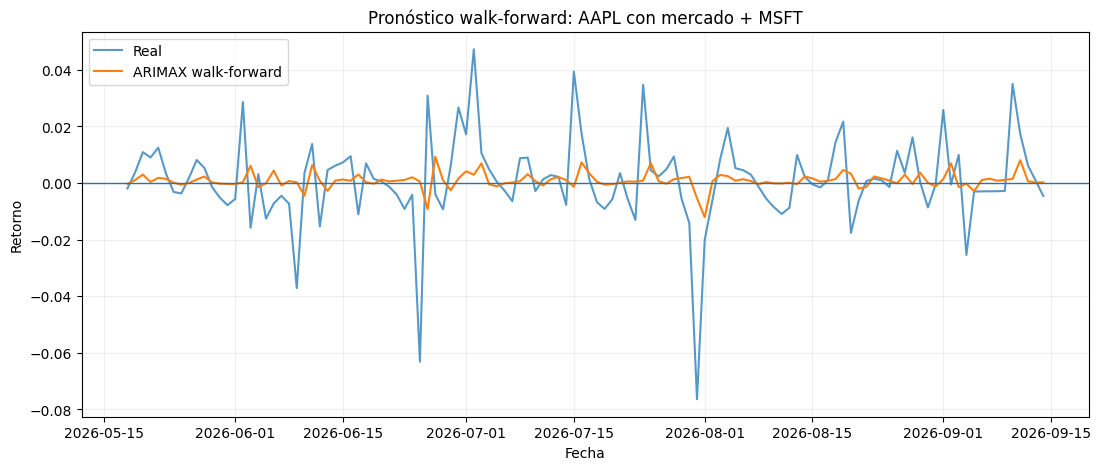

In [ ]:
plot_n = min(120, len(y_test))

plt.figure(figsize=(13, 5))

plt.plot(
    y_test.index[-plot_n:],
    y_test.iloc[-plot_n:],
    label="Real",
    alpha=0.75
)

plt.plot(
    pred_full_wf.index[-plot_n:],
    pred_full_wf.iloc[-plot_n:],
    label="ARIMAX walk-forward"
)

plt.axhline(0, linewidth=1)

plt.title(
    f"Pronóstico walk-forward: {TARGET} "
    f"con mercado + {PEER}"
)

plt.xlabel("Fecha")
plt.ylabel("Retorno")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# 27. Diagnóstico de residuos

Después de estimar un modelo debemos revisar qué información quedó sin capturar.

Primero estudiaremos la autocorrelación de los residuos.

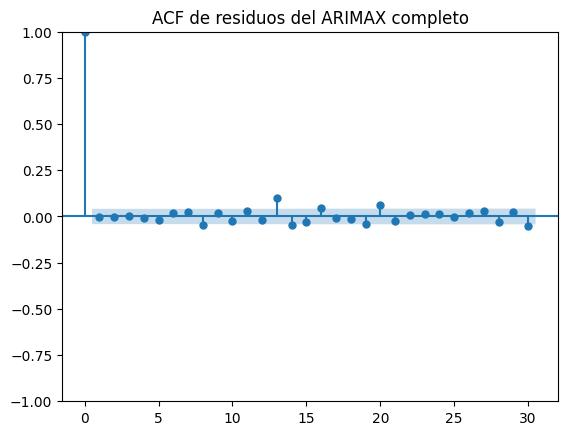

In [ ]:
residuals = pd.Series(
    np.asarray(model_full.resid)
).dropna()

fig = plot_acf(
    residuals,
    lags=30
)

plt.title(
    "ACF de residuos del ARIMAX completo"
)
plt.show()

## 27.1 Prueba de Ljung-Box

La hipótesis nula es:

$$
H_0:
\text{no existe autocorrelación conjunta hasta el rezago evaluado}
$$

Si los p-values son pequeños, todavía podría quedar estructura temporal en la media.

In [ ]:
ljung_box = acorr_ljungbox(
    residuals,
    lags=[5, 10, 20],
    return_df=True
)

ljung_box

,lb_stat,lb_pvalue
5,1.140225,0.950482
10,9.754056,0.462329
20,61.797803,0.000004


# 28. ¿Qué ocurre con la volatilidad?

Ahora observaremos los residuos al cuadrado.

Si aparece autocorrelación en:

$$
\varepsilon_t^2
$$

podría existir estructura temporal en la varianza, aunque la media ya esté razonablemente modelada.

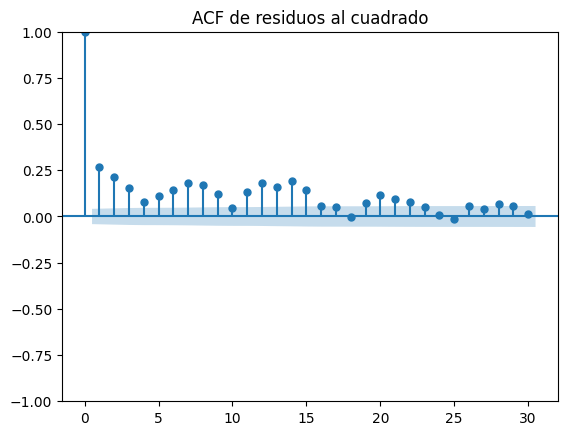

In [ ]:
fig = plot_acf(
    residuals ** 2,
    lags=30
)

plt.title(
    "ACF de residuos al cuadrado"
)
plt.show()

Esta observación nos conduce de manera natural a:

$$
ARCH
\rightarrow
GARCH
$$

ARIMA/ARIMAX se enfocan principalmente en la **media condicional**.

GARCH nos permitirá estudiar la **volatilidad condicional**.

# 29. Aplicación explicativa contemporánea

Para cerrar el vínculo con CAPM estimaremos también un modelo donde las X corresponden al mismo periodo:

$$
r^{AAPL}_t
=
c
+
\beta_m r^{MKT}_t
+
\beta_p r^{MSFT}_t
+
ARMA(p,q)
+
\varepsilon_t
$$

Este modelo responde a:

> **¿Cómo se asocian los movimientos simultáneos de mercado, Microsoft y Apple?**

Su finalidad principal es explicativa.

In [ ]:
contemp = data[
    ["target_ret", "market_ret", "peer_ret"]
].dropna().reset_index(drop=True)

split_c = int(
    len(contemp) * (1 - TEST_SIZE)
)

contemp_train = contemp.iloc[:split_c].copy()

y_c = pd.Series(
    contemp_train["target_ret"].to_numpy(),
    index=pd.RangeIndex(len(contemp_train))
)

X_c_raw = contemp_train[
    ["market_ret", "peer_ret"]
].copy()

mu_c = X_c_raw.mean()
sd_c = X_c_raw.std().replace(0, 1)

X_c_std = (X_c_raw - mu_c) / sd_c

X_c = pd.DataFrame(
    X_c_std.to_numpy(),
    index=pd.RangeIndex(len(contemp_train)),
    columns=["market_ret", "peer_ret"]
)

model_contemporaneous = SARIMAX(
    y_c,
    exog=X_c,
    order=(BEST_P, 0, BEST_Q),
    seasonal_order=(0, 0, 0, 0),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

pd.DataFrame({
    "coeficiente": model_contemporaneous.params,
    "p_value": model_contemporaneous.pvalues
})

,coeficiente,p_value
intercept,0.000782,0.000068
market_ret,0.008355,0.000000
peer_ret,0.003688,0.000000
ar.L1,0.170589,0.000000
ar.L2,-0.033578,0.111312
ar.L3,-0.049921,0.052361
sigma2,0.000078,0.000000


### Comparación conceptual

Si el peer contemporáneo parece importante, pero el peer rezagado no mejora el pronóstico, la lectura puede ser:

> Las empresas reaccionan a información común durante la misma rueda bursátil, pero el movimiento de Microsoft del día anterior no necesariamente contiene suficiente información para anticipar el retorno de Apple del día siguiente.

Esta diferencia es fundamental:

$$
\boxed{
explicar\ lo\ ocurrido
\neq
predecir\ lo\ que\ todavía\ no\ ocurrió
}
$$

# 30. Tabla final de desempeño

Convertiremos el RMSE del benchmark en una referencia para medir mejora porcentual.

In [ ]:
final_summary = walk_forward_results.copy()

naive_rmse = baseline_metrics["RMSE"]

final_summary["Mejora_RMSE_vs_Naive_%"] = (
    (naive_rmse - final_summary["RMSE"])
    / naive_rmse
    * 100
)

final_summary.sort_values("RMSE")

,Modelo,MAE,RMSE,Directional_Accuracy,Mejora_RMSE_vs_Naive_%
3,ARIMAX: mercado + peer,0.008716,0.014899,0.563055,0.643191
2,ARIMAX: mercado,0.008717,0.014900,0.561279,0.636284
1,ARIMA,0.008751,0.014964,0.541741,0.212658
0,Naive = 0,0.008878,0.014996,NaN,0.000000
